In [11]:
import pandas as pd

df = pd.read_csv("student_data.csv")
df.head()

,student_id,name,test_score,assignment_score,completion_rate,attendance,participation_score,login_frequency,study_time_hours
0,1,Student_1,77.450712,65.052060,90.597841,83.686733,67.254041,12,12.861525
1,2,Student_2,67.926035,68.277828,67.089685,76.066612,57.270700,15,12.872743
2,3,Student_3,79.715328,83.967523,92.174483,80.287448,67.201355,7,11.753903
3,4,Student_4,92.845448,82.324443,98.978930,92.784519,74.779365,19,10.078467
4,5,Student_5,66.487699,74.749181,85.788089,81.910991,65.879481,14,12.691445


In [12]:
print("Shape:", df.shape)
df.isnull().sum() 

Shape: (300, 9)


student_id             0
name                   0
test_score             0
assignment_score       0
completion_rate        0
attendance             0
participation_score    0
login_frequency        0
study_time_hours       0
dtype: int64

In [13]:
df['average_score'] = (df['test_score'] + df['assignment_score']) / 2

df['engagement_index'] = (
    0.4 * df['attendance'] +
    0.3 * df['participation_score'] +
    0.3 * (df['login_frequency'] / df['login_frequency'].max() * 100)
)

df['learning_consistency'] = 100 - abs(df['test_score'] - df['assignment_score'])

df[['average_score', 'engagement_index', 'learning_consistency']].head()

,average_score,engagement_index,learning_consistency
0,71.251386,66.064699,87.601348
1,68.101932,63.125096,99.648208
2,81.841426,59.516765,95.747805
3,87.584946,79.202789,89.478995
4,70.618440,67.010999,91.738519


In [14]:
from sklearn.preprocessing import StandardScaler

features_for_clustering = [
    'average_score', 'completion_rate', 'engagement_index',
    'learning_consistency', 'study_time_hours'
]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(df[features_for_clustering])

X_scaled[:5]   # pehli 5 rows dekho scaled values ki

array([[-0.10665178,  0.78885529, -0.18896113,  0.23398944,  0.73440071],
       [-0.45941424, -1.05129736, -0.56170519,  1.25549189,  0.737312  ],
       [ 1.07951183,  0.91227043, -1.01924461,  0.92476079,  0.44694127],
       [ 1.72282899,  1.44490353,  1.47695979,  0.39320285,  0.01211798],
       [-0.17754646,  0.41236135, -0.06896942,  0.58479704,  0.69026003]])

In [15]:
from sklearn.cluster import KMeans

kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
df['cluster'] = kmeans.fit_predict(X_scaled)

df['cluster'].value_counts()

cluster
0    109
1    104
2     87
Name: count, dtype: int64

In [16]:
cluster_means = df.groupby('cluster')['average_score'].mean().sort_values()
print(cluster_means)

ordered_clusters = cluster_means.index.tolist()

label_map = {
    ordered_clusters[0]: 'Slow Learner',
    ordered_clusters[1]: 'Moderate Learner',
    ordered_clusters[2]: 'Fast Learner'
}

df['learning_speed'] = df['cluster'].map(label_map)

df['learning_speed'].value_counts()

cluster
2    65.000959
1    73.941595
0    76.294146
Name: average_score, dtype: float64


learning_speed
Fast Learner        109
Moderate Learner    104
Slow Learner         87
Name: count, dtype: int64

In [17]:
from sklearn.metrics import silhouette_score, davies_bouldin_score

sil_score = silhouette_score(X_scaled, df['cluster'])
db_score = davies_bouldin_score(X_scaled, df['cluster'])

print(f"Silhouette Score: {sil_score:.3f}")
print(f"Davies-Bouldin Index: {db_score:.3f}")

Silhouette Score: 0.159
Davies-Bouldin Index: 1.837


C:\Users\dell\AppData\Local\Temp\ipykernel_4428\2730825568.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='learning_speed',


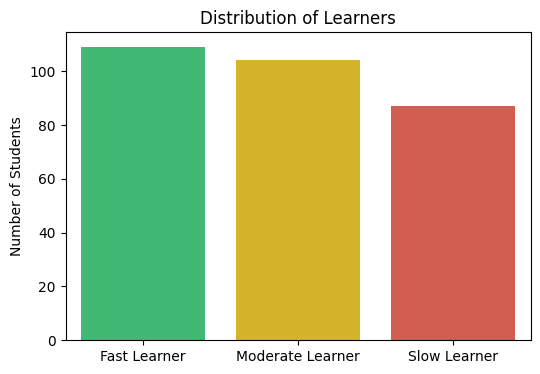

In [18]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(6,4))
sns.countplot(data=df, x='learning_speed',
              order=['Fast Learner', 'Moderate Learner', 'Slow Learner'],
              palette={'Fast Learner': '#2ecc71', 'Moderate Learner': '#f1c40f', 'Slow Learner': '#e74c3c'})
plt.title("Distribution of Learners")
plt.xlabel("")
plt.ylabel("Number of Students")
plt.show()

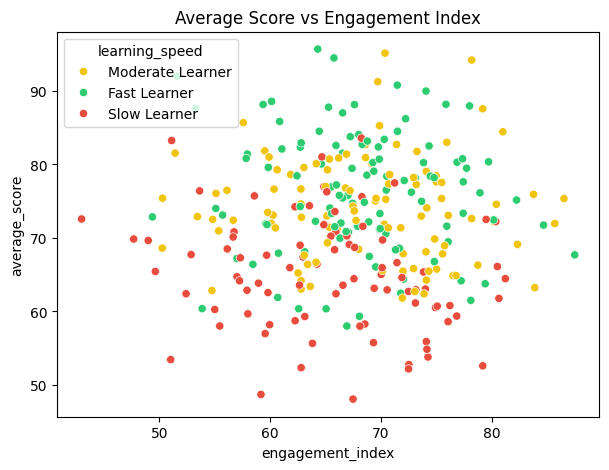

In [19]:
plt.figure(figsize=(7,5))
sns.scatterplot(
    data=df, x='engagement_index', y='average_score',
    hue='learning_speed',
    palette={'Fast Learner': '#2ecc71', 'Moderate Learner': '#f1c40f', 'Slow Learner': '#e74c3c'}
)
plt.title("Average Score vs Engagement Index")
plt.show()

In [20]:

df.to_csv("classified_students.csv", index=False)
print("Saved!")

Saved!
